This notebook serves as a demonstrations for how the affine effective Hamiltonian PMM is used to learn the ground state of the true underlying Hamiltonian

In [1]:
import numpy as np
from scipy.sparse import csr_matrix
import math
import jax.numpy as jnp
from jax import grad, lax, jit
from matplotlib import pyplot as plt
import sys

The Hamiltonian considered for this demonstration is the Transverse field Ising model: https://en.wikipedia.org/wiki/Transverse-field_Ising_model
$$H = -J(\sum_{\langle i,j\rangle} Z_iZ_j +g\sum_jX_j)$$


In [2]:
def Pauli(N):
    '''
    N: number of spins
    '''
    sigma = []
    for i in range(N):
        sig = []
        for j in range(3):
            sig.append(csr_matrix((2**N,2**N), dtype=np.complex128).toarray())
        sigma.append(sig)
    #pauli Z
    for nn in range(N):
        for jj in range(2**N):
            d_nn = math.floor(jj/2**nn)%2
            sigma[nn][2][jj][jj] = (-1)**(d_nn)
  #pauli x and y
    for nn in range(N):
        for jj in range(2**N):
            d_nn = math.floor(jj/2**nn)%2
            kk = jj  + (d_nn+1)%2*(2**nn) - d_nn*(2**nn)
            sigma[nn][0][kk][jj] = 1
            sigma[nn][1][kk][jj] = 1j*((-1)**(d_nn))
    return sigma

def Ising(N,J,g):
    '''
    N: number of spins
    J: coupling
    g: transverse field
    H = -J (sum_i sigma_z_i sigma_z_{i+1} + g sum_i sigma_x_i)
    '''
    sigma = Pauli(N)
    HA = csr_matrix((2**N,2**N), dtype=np.complex128)
    HB = csr_matrix((2**N,2**N), dtype=np.complex128)
    for nn in range(N):
            HA = HA + np.matmul(sigma[nn][2], sigma[(nn+1)%N][2]) #sigma z_i sigma z_j
            HB = HB + sigma[nn][0] #sigma x_j
    return -J*(HA + g*HB)

With the transverse field Ising model defined, we begin generating training and test data of the ground state energy $E_0(g)$ as a function of the transverse field strength $g$

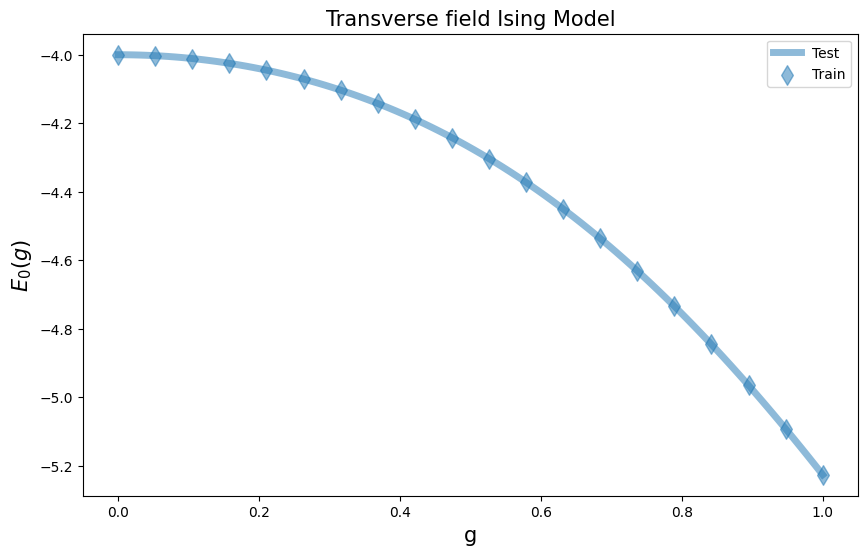

In [3]:
# Generate the data
g_test = np.linspace(0,1,100) #Transverse field strength
g_train = np.linspace(0,1,20)
N = 4 #number of spins
J = 1 #coupling constant

# Compute the ground state energy
E_test = []
for i in g_test:
    H = Ising(N,J,i)
    E_test.append(np.linalg.eigvalsh(H)[0])
E_test = np.array(E_test)
E_train = []
for i in g_train:
    H = Ising(N,J,i)
    E_train.append(np.linalg.eigvalsh(H)[0])
E_train = np.array(E_train)

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(g_test,E_test, lw=5, label = 'Test',alpha = 0.5)
plt.scatter(g_train,E_train, marker='d',s=100, label = 'Train',zorder=10,alpha=0.5)
plt.xlabel(r'g',fontsize=15)
plt.ylabel(r'$E_0(g)$',fontsize=15)
plt.title(r'Transverse field Ising Model',fontsize=15)
plt.legend()
plt.show()

Next we construct the affine effective Hamiltonian PMM

$$M(c) = A + cB$$

Where $c$ is the input parameter/coupling constant. In this example $c=g$.

The PMM is trained with Adam gradient descent method for complex parameters

In [4]:
def M(A: jnp.ndarray, B: jnp.ndarray, c: jnp.ndarray) -> jnp.ndarray:
    """
    PMM Hamiltonian M(c) = A + c*B

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [2D jax array (n, n)]: Hermitian matrix
    c [float or 1D jax array (N,)]: scalar or array of c values

    Returns
    -------
    M [2D (n, n) or 3D jax array (N, n, n)]: PMM Hamiltonian M(c) = A + c*B
        if c is a scalar, M is a 2D array M = A + c*B
        if c is an array, M is a 3D array M[i] = A + c[i]*B

    """
    # force Hermiticity
    A = (A + A.conj().T) / 2
    B = (B + B.conj().T) / 2

    if jnp.isscalar(c):
        return A + c * B

    else:
        return A + jnp.einsum("i,ijk->ijk", c, B[np.newaxis, :, :])


def get_eigen(
    A: jnp.ndarray, B: jnp.ndarray, cs: jnp.ndarray, k: int
) -> jnp.ndarray:
    """
    Get the k lowest eigenvalues of the PMM Hamiltonian M(c) = A + c*B

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [2D jax array (n, n)]: Hermitian matrix
    cs [1D jax array (N,)]: array of c values
    k [int <= n]: number of lowest eigenvalues to return

    Returns
    -------
    E [2D jax array (N, k)]: array of the k lowest eigenvalues of M(c) = A + c*B for
        each c in cs.
        E[i,j] is the j-th lowest eigenvalue of M(cs[i])
    """

    E = jnp.linalg.eigvalsh(M(A, B, cs))[:, :k]

    return E


def loss(
    A: jnp.ndarray, B: jnp.ndarray, cs: jnp.ndarray, Es: jnp.ndarray
) -> jnp.ndarray:
    """
    Mean Squared Error loss function between the eigenvalues of the PMM
    Hamiltonian M(c) = A + c*B and the target eigenvalues Es

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [2D jax array (n, n)]: Hermitian matrix
    cs [1D jax array (N,)]: array of c values
    Es [2D jax array (N, k)]: target eigenvalues at each c value
    """

    k = Es.shape[1]
    pmm_E = get_eigen(A, B, cs, k)
    return jnp.mean(jnp.abs(pmm_E - Es) ** 2)


def complex_adam_update(
    param: jnp.ndarray,
    grad: jnp.ndarray,
    lr: float,
    m: jnp.ndarray,
    v: jnp.ndarray,
    i: int,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps: float = 1e-8,
    absmaxgrad: float = 1e3,
) -> (jnp.ndarray, jnp.ndarray, jnp.ndarray):
    """
    Adam optimizer update rule, modified for complex valued parameters

    Parameters
    ----------
    param [jax array]: parameter to update
    grad [jax array]: gradient of the loss function wrt param
    lr [float]: learning rate
    m [jax array]: Adam optimizer first moment estimate
    v [jax array]: Adam optimizer second moment estimate
    i [int]: iteration number
    beta1 [float]: Adam optimizer first moment decay rate
    beta2 [float]: Adam optimizer second moment decay rate
    eps [float]: Adam optimizer epsilon parameter
    absmaxgrad [float]: maximum absolute value of the gradient for clipping

    Returns
    -------
    param [jax array]: updated parameter
    m [jax array]: updated first moment estimate
    v [jax array]: updated second moment
    """

    # for complex valued parameters, conjugate the gradient
    # as the gradient descent update rule is
    # x = x - lr * dL/dconj(x)
    # which for real-valued loss functions is equivalent to
    # x = x - lr * conj(dL/dx)

    # we also clip the gradient to avoid exploding gradients
    conj_grad = jnp.clip(grad.real, -absmaxgrad, absmaxgrad) - 1j * jnp.clip(
        grad.imag, -absmaxgrad, absmaxgrad
    )

    # moment estimates
    m = beta1 * m + (1 - beta1) * conj_grad
    v = beta2 * v + (1 - beta2) * jnp.abs(conj_grad) ** 2
    # bias correction
    mhat = m / (1 - beta1 ** (i + 1))
    vhat = v / (1 - beta2 ** (i + 1))

    # update rule
    param = param - lr * mhat / (jnp.sqrt(vhat) + eps)

    return param, m, v


def train(
    A: jnp.ndarray,
    B: jnp.ndarray,
    cs_train: jnp.ndarray,
    Es_train: jnp.ndarray,
    lr: float = 1e-3,
    n_iter: int = 1000,
    ):
    """
    Train the PMM Hamiltonian M(c) = A + c*B to match target eigenvalues
    Es_train at c values cs_train

    Parameters
    ----------
    A [2D jax array (n, n)]: Initial guess for Hermitian matrix A
    B [2D jax array (n, n)]: Initial guess for Hermitian matrix B
    cs_train [1D jax array (N,)]: array of c values to train on
    Es_train [2D jax array (N, k)]: target eigenvalues at each c value
    lr [float]: learning rate
    n_iter [int]: number of training iterations

    Returns
    -------
    A [2D jax array (n, n)]: trained Hermitian matrix A
    B [2D jax array (n, n)]: trained Hermitian matrix B
    """

    # initialize Adam optimizer
    m_A = jnp.zeros_like(A)
    v_A = jnp.zeros_like(A)
    m_B = jnp.zeros_like(B)
    v_B = jnp.zeros_like(B)

    # jit version of the loss function
    j_loss = jit(loss)

    # gradient of the loss function wrt A and B
    grad_loss = grad(j_loss, argnums=(0, 1))

    # training loop
    for i in range(n_iter):

        # compute the gradient of the loss function
        grad_A, grad_B = grad_loss(A, B, cs_train, Es_train)

        # update A and B
        A, m_A, v_A = complex_adam_update(A, grad_A, lr, m_A, v_A, i)
        B, m_B, v_B = complex_adam_update(B, grad_B, lr, m_B, v_B, i)

        # print loss every 100 iterations
        if i % 100 == 0:
            sys.stdout.write(f"\rIteration {i: <7}, Loss: {j_loss(A, B, cs_train, Es_train): .4E}")
            sys.stdout.flush()

    sys.stdout.write("\n")
    sys.stdout.flush()

    # force resulting A and B to be Hermitian
    A = (A + A.conj().T)/2
    B = (B + B.conj().T)/2

    return A, B

def predict(A: jnp.ndarray, B: jnp.ndarray, cs: jnp.ndarray, k: int) -> jnp.ndarray:
    """
    Use the trained PMM Hamiltonian M(c) = A + c*B to predict the k lowest
    eigenvalues

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [2D jax array (n, n)]: Hermitian matrix
    cs [1D jax array (N,)]: array of c values
    k [int <= n]: number of lowest eigenvalues to return

    Returns
    -------
    E [2D jax array (N, k)]: array of the k lowest eigenvalues of M(c) = A + c*B for
        each c in cs.
        E[i,j] is the j-th lowest eigenvalue of M(cs[i])
    """

    return get_eigen(A, B, cs, k)


With the PMM defined, we can begin training the model by minimizing the mean squared error between the true ground state and the predicted ground stae

In [5]:
X_train = jnp.array(g_train) # input
y_train = jnp.array(E_train).reshape(-1,1) # output

# initialize the PMM parameters
n = 4 # size of nxn PMM
k = 1 # number of lowest eigenvalues to predict
lr = 0.01 # learning rate
iterations = 10000 # number of training iterations

# training data consists only of the k lowest eigenvalues
y_train_k = y_train[:, :k]

np.random.seed(42)

# multiply all initial 'weights' by a small prefactor to help with training
mag = 1e-1

# Initialize A matrix
A = np.random.randn(n, n) + 1j * np.random.randn(n, n)  # initialize the parameters
A = (A + A.conj().T)/2
A = mag * jnp.array(A)

# Initialize B matrix
B = np.random.randn(n, n) + 1j * np.random.randn(n, n)  # initialize the parameters
B = (B + B.conj().T)/2
B = mag * jnp.array(B)

# train the model
A, B = train(A, B, X_train, y_train_k, lr=lr, n_iter=iterations)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Iteration 9900   , Loss:  3.7767E-06


Finally we use the trained PMM parameters to make a prediction on unseen data

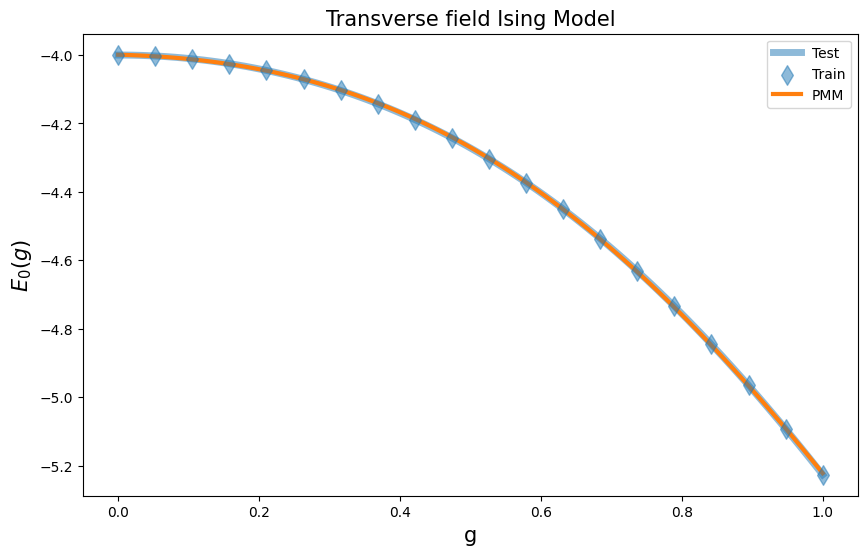

In [6]:
# make prediction
X_test = jnp.array(g_test)
y_test = jnp.array(E_test).reshape(-1,1)
y_pred = predict(A, B, X_test, k)

# plot figure
plt.figure(figsize=(10,6))
plt.plot(g_test,y_test,lw =5, label = 'Test',alpha = 0.5)
plt.scatter(g_train,y_train,marker='d',s=100, label = 'Train',zorder=10,alpha=0.5)
plt.plot(g_test,y_pred,lw=3, label = 'PMM')
plt.xlabel(r'g',fontsize=15)
plt.ylabel(r'$E_0(g)$',fontsize=15)
plt.title(r'Transverse field Ising Model',fontsize=15)
plt.legend()
plt.show()

Additionally, we can read out the matrix elements of the PMM.

In [7]:
A_disp = np.array2string(A, precision=4, floatmode='fixed')
B_disp = np.array2string(B, precision=4, floatmode='fixed')

print("=== A ===")
print(A_disp)
print("=== B ===")
print(B_disp)

=== A ===
[[-1.0575+0.0000j -0.3689-0.7463j  0.7958+0.2655j  1.2546-0.5849j]
 [-0.3689+0.7463j -0.5638+0.0000j  0.5322-0.4002j -0.0546-0.9581j]
 [ 0.7958-0.2655j  0.5322+0.4002j -0.6709+0.0000j -0.8006+0.7376j]
 [ 1.2546+0.5849j -0.0546+0.9581j -0.8006-0.7376j -1.5584+0.0000j]]
=== B ===
[[-0.4662+0.0000j -0.8317-0.1649j  0.7949+0.1477j -1.1370+0.1475j]
 [-0.8317+0.1649j -1.1675+0.0000j  0.9522-0.0131j -0.9147+0.4277j]
 [ 0.7949-0.1477j  0.9522+0.0131j -0.9887+0.0000j  0.9698-0.1164j]
 [-1.1370-0.1475j -0.9147-0.4277j  0.9698+0.1164j -0.3639+0.0000j]]
